# TP3 - Detección del logo Coca-Cola

Se busca el logo en cada imagen de `Material_TPs/TP3/images/` a partir del template `Material_TPs/TP3/template/pattern.png`.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120

base_dir = Path(r'D:\Master\TP3\Material_TPs\TP3')
template_path = base_dir / 'template' / 'pattern.png'
image_dir = base_dir / 'images'
image_paths = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg'))

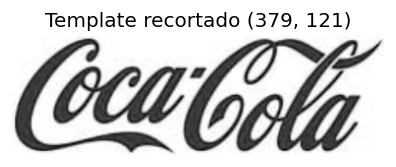

In [2]:
def iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return 0.0 if union <= 0 else inter / union


def nms(boxes, iou_threshold=0.2):
    kept = []
    for box in sorted(boxes, key=lambda b: b[4], reverse=True):
        if all(iou(box, prev) <= iou_threshold for prev in kept):
            kept.append(box)
    return kept


def high_pass(gray):
    """Resta un blur gaussiano grande para eliminar gradientes de iluminación."""
    gray = gray.astype(np.float32)
    sigma = max(gray.shape) / 20
    return gray - cv.GaussianBlur(gray, (0, 0), sigma)


def load_template(path):
    tpl = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    # Recorte al bounding box del logo (se descarta el fondo blanco sobrante)
    ys, xs = np.where(tpl < 200)
    pad = 3
    return tpl[max(0, ys.min() - pad):ys.max() + pad + 1, max(0, xs.min() - pad):xs.max() + pad + 1]


template = load_template(template_path)
plt.figure(figsize=(4, 2))
plt.imshow(template, cmap='gray')
plt.title(f'Template recortado {template.shape[::-1]}')
plt.axis('off')
plt.show()

In [3]:
def match_candidates(img_bgr, template, min_width=40, n_scales=40,
                     aspect_ratios=(1.0, 1.2, 1.4, 1.6), min_score=0.2,
                     border_fractions=(0.5, 0.6, 0.7, 0.8, 0.9)):
    """Template matching multiescala. Devuelve candidatos (x1, y1, x2, y2, score).

    - ancho del template: de `min_width` px hasta el 95% del ancho de la imagen (escala geométrica)
    - aspect_ratios: factor de estiramiento vertical (logos sobre superficies curvas)
    - score = |TM_CCOEFF_NORMED| -> invariante a la inversión de contraste
    - border_fractions: fracciones visibles del template para logos cortados por el borde
    """
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    H, W = gray.shape
    img_hp = high_pass(gray)
    tpl_h, tpl_w = template.shape

    candidates = []
    for tw in np.unique(np.geomspace(min_width, W * 0.95, n_scales).astype(int)):
        for ar in aspect_ratios:
            th = int(tw * tpl_h / tpl_w * ar)
            if th >= H or tw >= W:
                continue
            tpl_resized = cv.resize(template, (tw, th), interpolation=cv.INTER_AREA)
            result = np.abs(cv.matchTemplate(img_hp, high_pass(tpl_resized), cv.TM_CCOEFF_NORMED))

            # máximos locales por encima del umbral mínimo
            local_max = (result == cv.dilate(result, np.ones((5, 5), np.uint8))) & (result >= min_score)
            for y, x in zip(*np.where(local_max)):
                candidates.append((int(x), int(y), int(x + tw), int(y + th), float(result[y, x])))

            if border_fractions:
                candidates += match_at_borders(img_hp, high_pass(tpl_resized), border_fractions, min_score)
    return candidates


def match_at_borders(img_hp, tpl_hp, fractions, min_score):
    """Logos cortados por el borde izquierdo/derecho de la imagen.

    Se compara sólo la parte visible del template (una fracción `f` de su ancho)
    contra la franja de la imagen pegada al borde. El bounding box es la parte visible.
    """
    H, W = img_hp.shape
    th, tw = tpl_hp.shape
    candidates = []
    for f in fractions:
        kw = int(tw * f)
        if kw < 30 or kw >= W:
            continue
        # borde izquierdo: se ve la parte derecha del logo
        result = np.abs(cv.matchTemplate(img_hp[:, :kw], tpl_hp[:, tw - kw:], cv.TM_CCOEFF_NORMED))[:, 0]
        y = int(result.argmax())
        if result[y] >= min_score:
            candidates.append((0, y, kw, y + th, float(result[y])))
        # borde derecho: se ve la parte izquierda del logo
        result = np.abs(cv.matchTemplate(img_hp[:, W - kw:], tpl_hp[:, :kw], cv.TM_CCOEFF_NORMED))[:, 0]
        y = int(result.argmax())
        if result[y] >= min_score:
            candidates.append((W - kw, y, W, y + th, float(result[y])))
    return candidates


def draw_detections(img_bgr, detections, title):
    img = img_bgr.copy()
    thickness = max(2, img.shape[1] // 400)
    font_scale = max(0.4, img.shape[1] / 1600)
    for x1, y1, x2, y2, score in detections:
        cv.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), thickness)
        label = f'{score:.2f}'
        (lw, lh), _ = cv.getTextSize(label, cv.FONT_HERSHEY_SIMPLEX, font_scale, 1)
        ty = y1 - 4 if y1 - lh - 6 > 0 else y2 + lh + 4
        cv.rectangle(img, (x1, ty - lh - 3), (x1 + lw + 2, ty + 3), (0, 255, 0), -1)
        cv.putText(img, label, (x1 + 1, ty), cv.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), 1, cv.LINE_AA)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## 1. Una detección por imagen

Se toma el candidato de mayor score de cada imagen.

COCA-COLA-LOGO.jpg: bbox=(78,476,1284,861) score=0.638


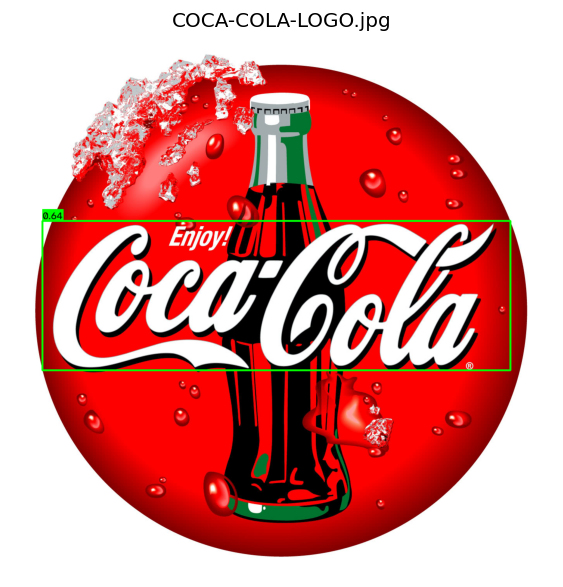

coca_logo_1.png: bbox=(34,210,194,261) score=0.485


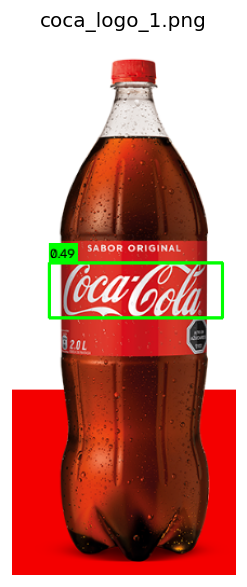

coca_logo_2.png: bbox=(3,124,224,208) score=0.311


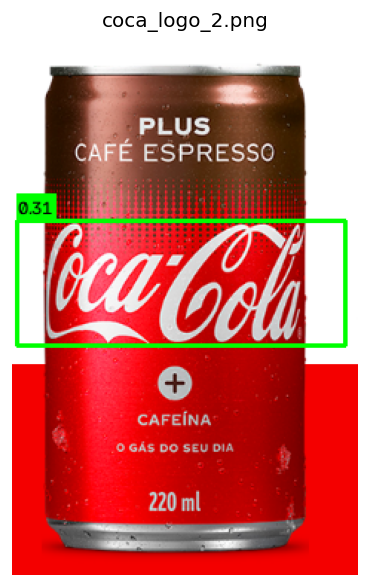

coca_multi.png: bbox=(707,156,798,185) score=0.480


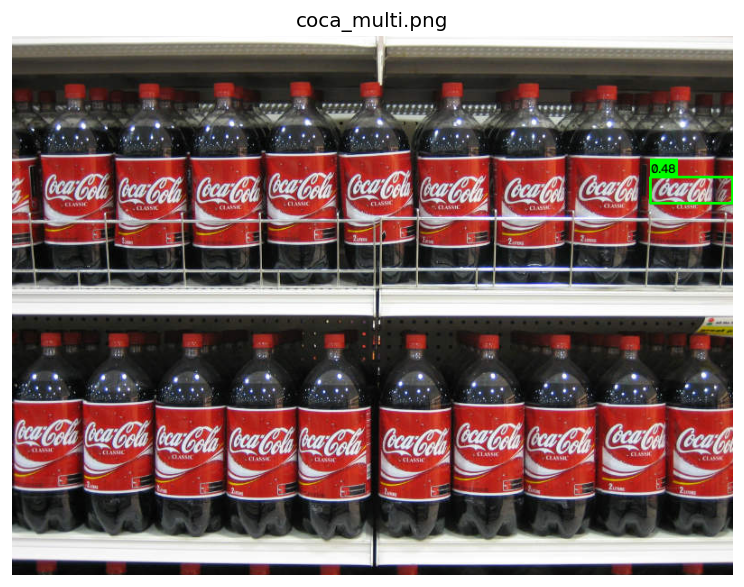

coca_retro_1.png: bbox=(109,106,617,268) score=0.635


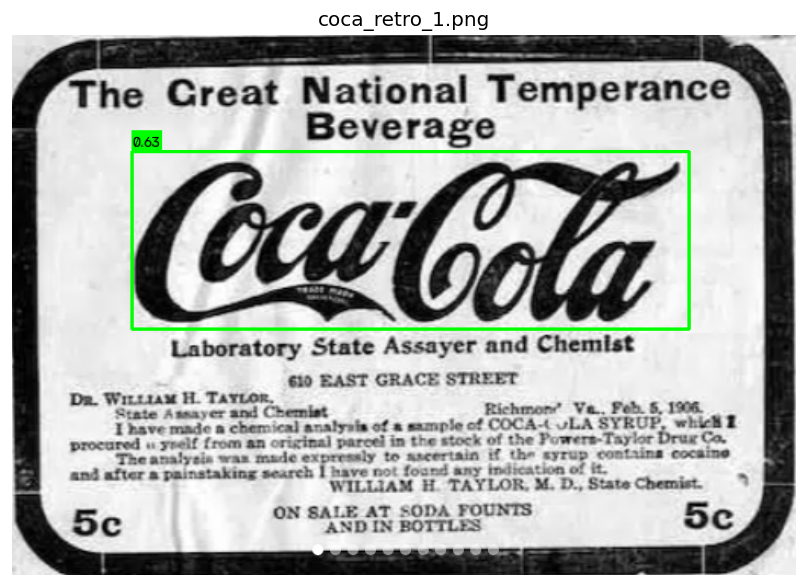

coca_retro_2.png: bbox=(64,195,211,241) score=0.608


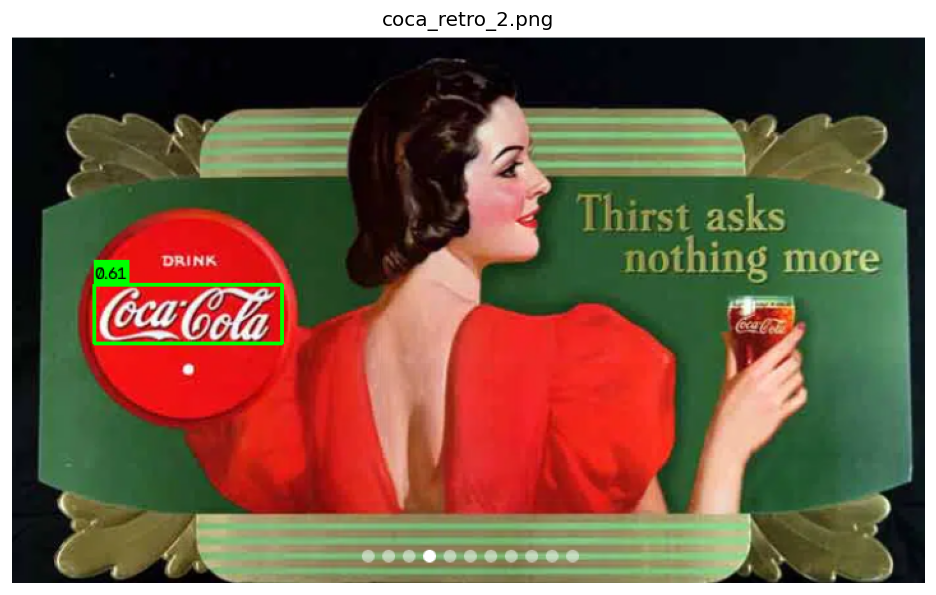

logo_1.png: bbox=(205,212,481,300) score=0.386


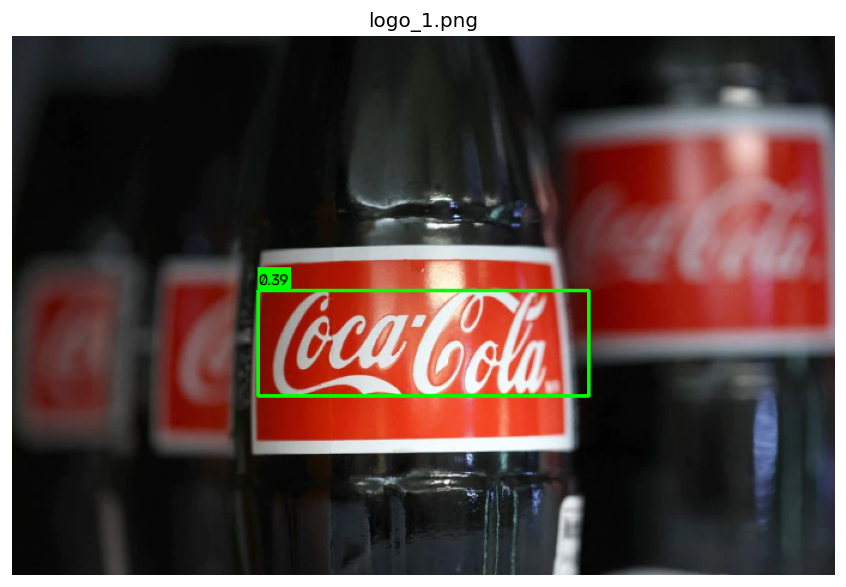

In [4]:
def detect_single(img_bgr, template):
    # para el ítem 1 sólo se usa el template completo (sin logos cortados por el borde)
    candidates = match_candidates(img_bgr, template, border_fractions=())
    if not candidates:
        return []
    return [max(candidates, key=lambda b: b[4])]


for image_path in image_paths:
    img = cv.imread(str(image_path), cv.IMREAD_COLOR)
    detections = detect_single(img, template)
    for x1, y1, x2, y2, score in detections:
        print(f'{image_path.name}: bbox=({x1},{y1},{x2},{y2}) score={score:.3f}')
    draw_detections(img, detections, image_path.name)

## 2. Múltiples detecciones en `coca_multi.png`

Se conservan todos los máximos locales y se aplica NMS. Además, para los logos **cortados por el borde** de la imagen (las botellas de los extremos), se compara sólo la parte visible del template (50–90 % de su ancho) contra la franja pegada al borde.

Al ordenar los scores aparece un salto claro: los logos tienen score ≥ 0.33, mientras que el primer falso positivo queda en 0.27. Por eso se usa un umbral de **0.30**.

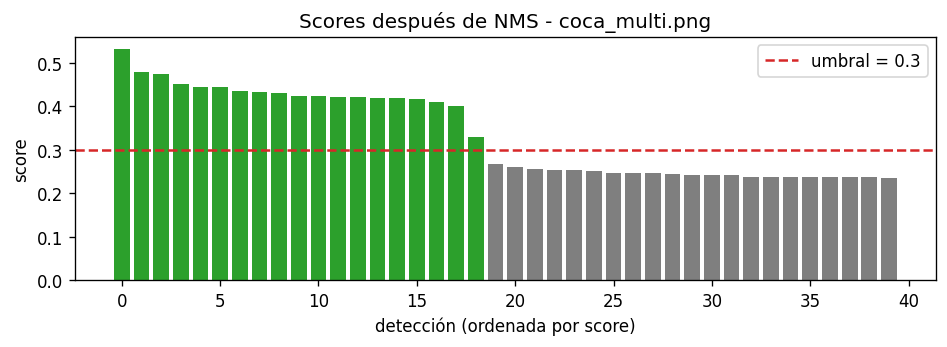

19 detecciones


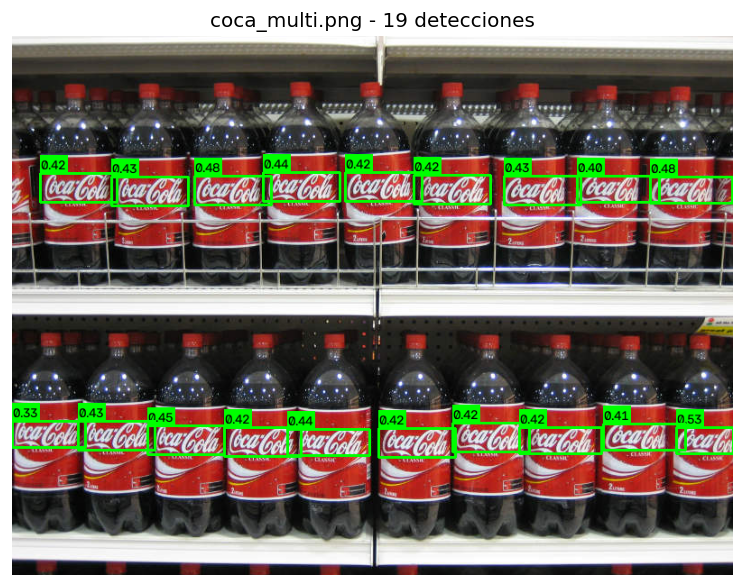

In [5]:
DETECTION_THRESHOLD = 0.30

multi_path = image_dir / 'coca_multi.png'
img_multi = cv.imread(str(multi_path), cv.IMREAD_COLOR)
all_dets = nms(match_candidates(img_multi, template), iou_threshold=0.2)

scores = [d[4] for d in all_dets[:40]]
plt.figure(figsize=(8, 3))
plt.bar(range(len(scores)), scores, color=['tab:green' if s >= DETECTION_THRESHOLD else 'tab:gray' for s in scores])
plt.axhline(DETECTION_THRESHOLD, color='tab:red', linestyle='--', label=f'umbral = {DETECTION_THRESHOLD}')
plt.xlabel('detección (ordenada por score)')
plt.ylabel('score')
plt.title('Scores después de NMS - coca_multi.png')
plt.legend()
plt.tight_layout()
plt.show()

multi_dets = [d for d in all_dets if d[4] >= DETECTION_THRESHOLD]
print(f'{len(multi_dets)} detecciones')
draw_detections(img_multi, multi_dets, f'coca_multi.png - {len(multi_dets)} detecciones')

## 3. Generalización a todas las imágenes

En todas las imágenes los falsos positivos quedan en ≤ 0.27, así que además se conserva siempre la mejor detección de cada imagen.

COCA-COLA-LOGO.jpg: 1 detecciones


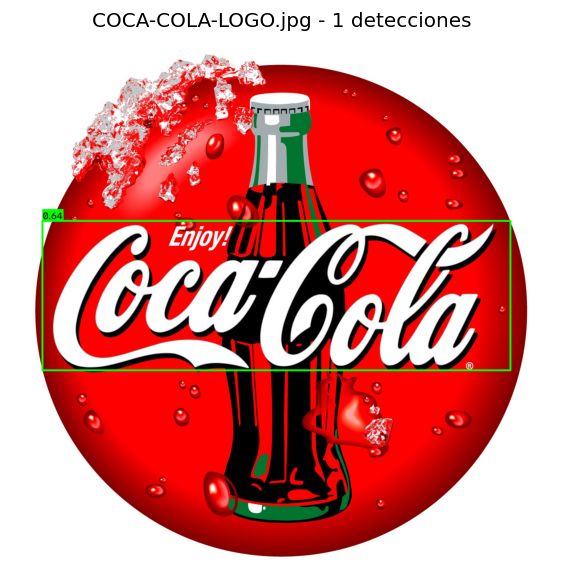

coca_logo_1.png: 1 detecciones


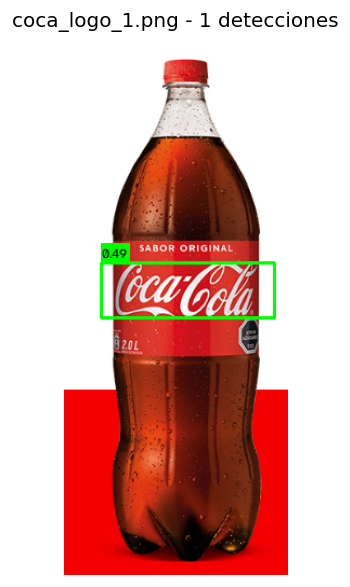

coca_logo_2.png: 1 detecciones


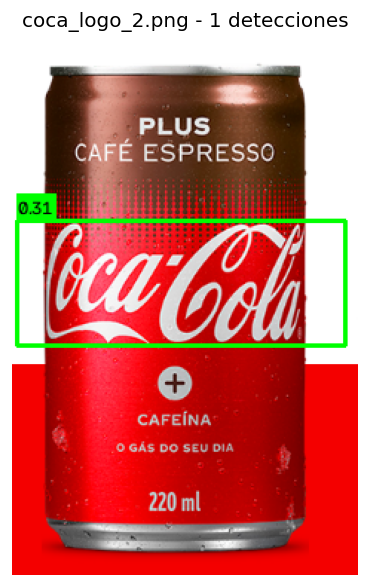

coca_multi.png: 19 detecciones


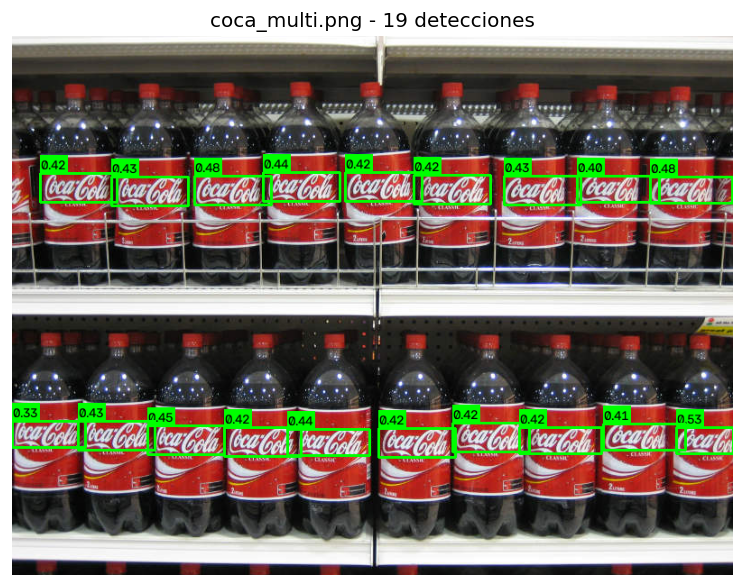

coca_retro_1.png: 1 detecciones


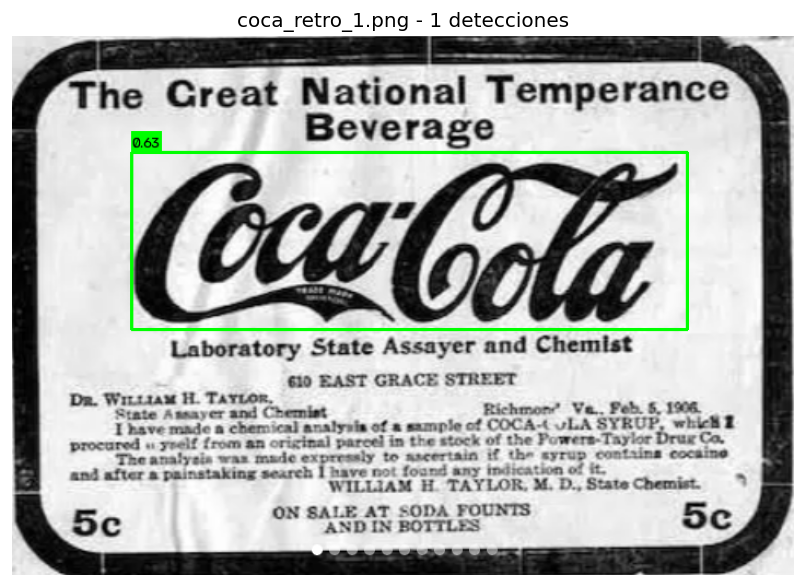

coca_retro_2.png: 2 detecciones


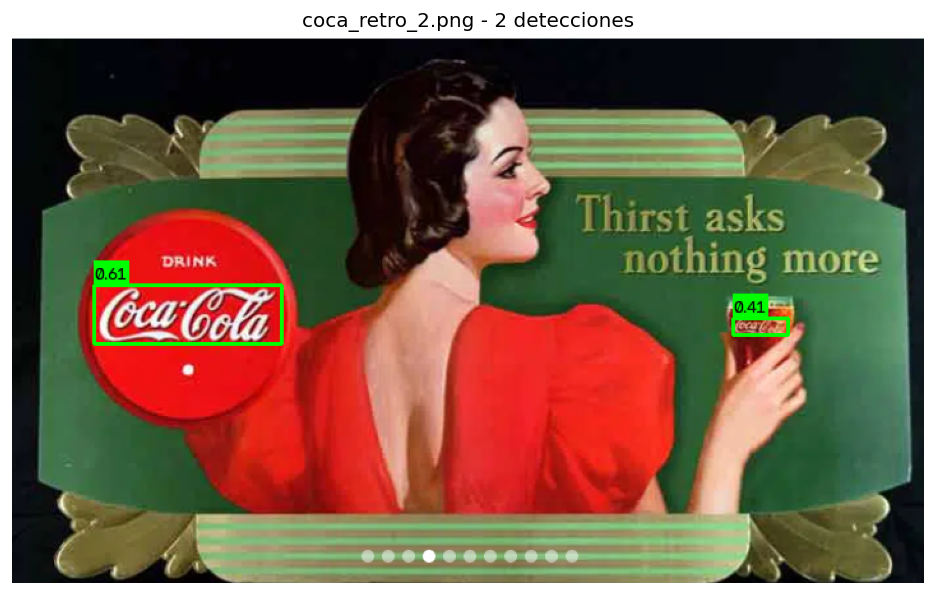

logo_1.png: 1 detecciones


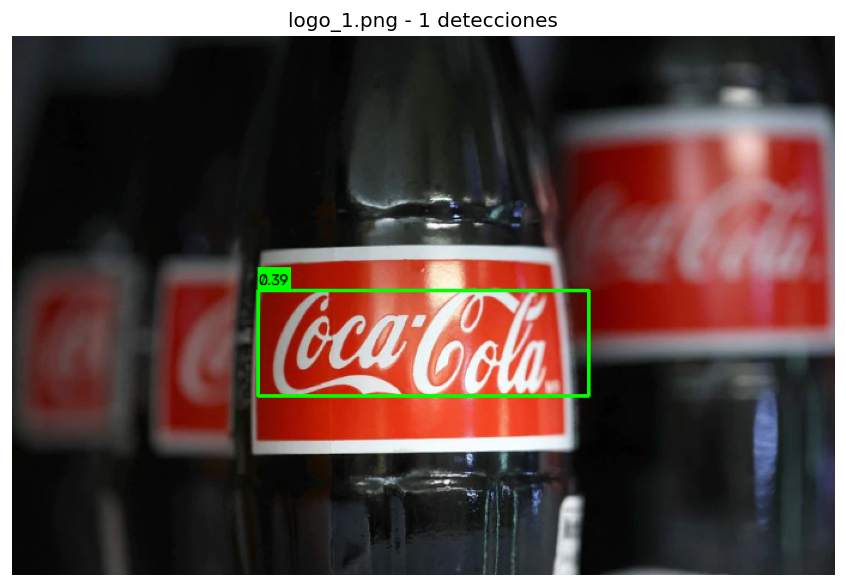

In [6]:
def detect_multi(img_bgr, template, threshold=DETECTION_THRESHOLD, iou_threshold=0.2):
    dets = nms(match_candidates(img_bgr, template), iou_threshold=iou_threshold)
    if not dets:
        return []
    return [dets[0]] + [d for d in dets[1:] if d[4] >= threshold]


for image_path in image_paths:
    img = cv.imread(str(image_path), cv.IMREAD_COLOR)
    detections = detect_multi(img, template)
    print(f'{image_path.name}: {len(detections)} detecciones')
    draw_detections(img, detections, f'{image_path.name} - {len(detections)} detecciones')